# EDA

### Libraries and constants

In [ ]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from utils import (
    auto_iqr_winsorization_limits,
    calculate_feature_psi,
    check_stationarity,
    detect_perfect_multicollinearity_via_rank,
    find_redundant_columns_qr,
    get_null_info,
    perform_advanced_vif_analysis,
    render_correlations,
    run_acorr_ljungbox_for_classification_residuals,
    screen_autocorrelation_stage1,
    target_info,
)

In [2]:
# --- Settings ---
pd.set_option('display.float_format', lambda x: f'{x:.6f}') # turn off exponent format (1e-12) for data frames, use float format instead

In [3]:
# --- CONSTANTS ---
RANDOM_SEED = 42
TARGET_NAME = 'state'

### Data import and processing

In [4]:
def obtain_time_domain_features(df: pd.DataFrame) -> dict:
    """Extracts time domain features from the 3D accelerometer signal."""
    data_window = {}
    axes = ['accelerometer_X', 'accelerometer_Y', 'accelerometer_Z']
    short_names = {'accelerometer_X': 'X', 'accelerometer_Y': 'Y', 'accelerometer_Z': 'Z'}

    for axis in axes:
        values = df[axis].to_numpy()
        name = short_names[axis]

        mean_val = np.mean(values)
        max_val = np.max(values)
        min_val = np.min(values)

        data_window[f'mean_{name}'] = mean_val
        data_window[f'var_{name}'] = np.var(values)
        data_window[f'std_{name}'] = np.std(values)
        data_window[f'median_{name}'] = np.median(values)
        data_window[f'max_{name}'] = max_val
        data_window[f'min_{name}'] = min_val
        data_window[f'range_{name}'] = max_val - min_val
        data_window[f'rms_{name}'] = np.sqrt(np.mean(values**2))
        data_window[f'skew_{name}'] = stats.skew(values)
        data_window[f'kurt_{name}'] = stats.kurtosis(values)
        data_window[f'iqr_{name}'] = stats.iqr(values)
        data_window[f'mad_{name}'] = np.mean(np.abs(values - mean_val))
        data_window[f'power_{name}'] = np.mean(values**2)
        data_window[f'energy_{name}'] = np.sum(values**2)

        counts, _ = np.histogram(values, bins=10)
        probs = counts / len(values)
        probs = probs[probs > 0]
        data_window[f'entropy_{name}'] = -np.sum(probs * np.log2(probs))

        data_window[f'idx_max_{name}'] = np.argmax(values)
        data_window[f'idx_min_{name}'] = np.argmin(values)

    x_vals = df['accelerometer_X'].to_numpy()
    y_vals = df['accelerometer_Y'].to_numpy()
    z_vals = df['accelerometer_Z'].to_numpy()

    data_window['sma'] = np.mean(np.abs(x_vals) + np.abs(y_vals) + np.abs(z_vals))
    data_window['corr_XY'] = np.corrcoef(x_vals, y_vals)[0, 1]
    data_window['corr_XZ'] = np.corrcoef(x_vals, z_vals)[0, 1]
    data_window['corr_YZ'] = np.corrcoef(y_vals, z_vals)[0, 1]

    return data_window

def obtain_frequency_domain_features(df: pd.DataFrame) -> dict:
    """Extracts frequency domain features (FFT) from the signal."""
    data_window = {}
    axes = ['accelerometer_X', 'accelerometer_Y', 'accelerometer_Z']
    short_names = {'accelerometer_X': 'X', 'accelerometer_Y': 'Y', 'accelerometer_Z': 'Z'}

    for axis in axes:
        values = df[axis].to_numpy()
        name = short_names[axis]
        n = len(values)

        fft_coeffs = np.fft.rfft(values)
        fft_mag = np.abs(fft_coeffs)
        fft_sq = fft_mag ** 2

        data_window[f'fft_band_power_{name}'] = np.sum(fft_sq) / n
        data_window[f'fft_energy_{name}'] = np.sum(fft_sq)
        data_window[f'fft_dc_{name}'] = fft_mag[0] # Zero-frequency bin (DC)
        data_window[f'fft_magnitude_{name}'] = np.mean(fft_mag[1:]) # Mean of rest
        data_window[f'fft_max_{name}'] = np.max(fft_mag)
        data_window[f'fft_min_{name}'] = np.min(fft_mag)

    return data_window

In [5]:
# final result
df_data = []

# each folder is a unique class
for cl in ['idle', 'running', 'stairs', 'walking']:
    path = Path('data') / cl

    if not path.exists():
        print(f"Warning: Path {path} does not exist. Skipping.")
        continue

    # 1. Safely find and collect ONLY valid files with their sequence numbers
    valid_files = []
    for f in path.iterdir():
        # Make sure it's a file and ends with .csv (ignores hidden folders/files)
        if f.is_file() and f.suffix.lower() == '.csv':
            # Extract the digit sequence from the filename
            match = re.search(r'\d+', f.stem)
            if match:
                file_number = int(match.group())
                valid_files.append((file_number, f))
            else:
                print(f"Skipping file (no number found): {f.name}")

    # 2. Sort the files numerically by that extracted number
    valid_files.sort(key=lambda x: x[0])

    # Extract just the sorted Path objects
    sorted_files = [item[1] for item in valid_files]

    # 3. Process the safely sorted files
    for f in sorted_files:
        # Read the file
        csv = pd.read_csv(f)

        # Normalize the data BEFORE feature extraction
        for axis in ['accelerometer_X', 'accelerometer_Y', 'accelerometer_Z']:
            mean = csv[axis].mean()
            std = csv[axis].std()
            if std > 0:
                csv[axis] = (csv[axis] - mean) / std
            else:
                csv[axis] = csv[axis] - mean

        # Extract all features using the normalized data
        time_feats = obtain_time_domain_features(csv)
        freq_feats = obtain_frequency_domain_features(csv)

        # Merge the dictionaries and add the target label
        row = {**time_feats, **freq_feats, TARGET_NAME: cl}
        df_data.append(row)

# Create final DataFrame
df = pd.DataFrame(df_data)

The research doesn't explicitly specify whether the data was collected from one person or many. For multiple groups, we would have to consider the order in blocks. The files are also named in an ordinal manner which makes us suspicious about whether the temporal order is important here. If it is, we're dealing with a time-series problem.

By checking how different the magnitudes of the numbers are in small consecutive chunks, we will be able to tell exactly if it's a cohesive one-person activity. We are considering only active classes (running and walking) where numbers are truly different.

In [6]:
for cl in ['running', 'walking']:
    path = Path('data') / cl

    # Safely find files that have numbers in them
    valid_files = []
    for f in path.iterdir():
        if f.is_file():
            # Looks for any digits in the filename
            match = re.search(r'\d+', f.stem)
            if match:
                valid_files.append((int(match.group()), f))

    # Sort files by their extracted number
    valid_files.sort(key=lambda x: x[0])
    files = [f[1] for f in valid_files]

    # Only check if we found enough files
    if len(files) < 6:
        print(f"Not enough sequential files found in {path}. Found: {len(files)}")
        continue

    print(f"--- Checking continuity for class: {cl} ---")
    for i in range(5):  # check first 5 transitions
        last_row  = pd.read_csv(files[i]).iloc[-1]
        first_row = pd.read_csv(files[i+1]).iloc[0]

        print(f"File {files[i].name} last row values:")
        print(f"  {last_row.to_dict()}")
        print(f"File {files[i+1].name} first row values:")
        print(f"  {first_row.to_dict()}")
        print("-" * 40)

--- Checking continuity for class: running ---
File running-1.csv last row values:
  {'accelerometer_X': -0.2585739999999999, 'accelerometer_Y': 9.414001, 'accelerometer_Z': 3.96001}
File running-2.csv first row values:
  {'accelerometer_X': 1.762132, 'accelerometer_Y': 4.242526, 'accelerometer_Z': 8.078037}
----------------------------------------
File running-2.csv last row values:
  {'accelerometer_X': 10.405201, 'accelerometer_Y': 8.322245, 'accelerometer_Z': 1.3982139999999998}
File running-3.csv first row values:
  {'accelerometer_X': 5.573702, 'accelerometer_Y': 13.43626, 'accelerometer_Z': 15.05474}
----------------------------------------
File running-3.csv last row values:
  {'accelerometer_X': 25.914839, 'accelerometer_Y': 0.799663, 'accelerometer_Z': 8.872911}
File running-4.csv first row values:
  {'accelerometer_X': -4.941632, 'accelerometer_Y': 3.677494, 'accelerometer_Z': 4.376601}
----------------------------------------
File running-4.csv last row values:
  {'accelero

Looking at what rows actually are, we may conclude that these are independent files. The jumps are enormous and completely random in direction — running goes from (−0.26, 9.41, 3.96) to (1.76, 4.24, 8.08), then the next boundary is (10.4, 8.3, 1.4) to (5.6, 13.4, 15.1). There's no physical continuity — a body in motion cannot teleport between these positions in one sample step. These are separate INDEPENDENT recordings. They are not-time ordered, even though the file names seem ordered. We may shuffle the data.

## Data cleaning

### Data overview and typing

In [7]:
display(df.head())
print(df.shape)

,mean_X,var_X,std_X,median_X,max_X,min_X,range_X,rms_X,skew_X,kurt_X,...,fft_magnitude_Y,fft_max_Y,fft_min_Y,fft_band_power_Z,fft_energy_Z,fft_dc_Z,fft_magnitude_Z,fft_max_Z,fft_min_Z,state
0,0.000000,0.966667,0.983192,-0.271525,4.748541,-1.050064,5.798605,0.983192,3.839216,15.400041,...,4.828593,7.855532,0.000000,14.506982,435.209455,0.000000,4.281670,11.798137,0.000000,idle
1,0.000000,0.966667,0.983192,-0.218708,4.883959,-1.001930,5.885889,0.983192,4.185307,17.579254,...,5.127667,11.223024,0.000000,14.504438,435.133152,0.000000,4.611639,8.711034,0.000000,idle
2,-0.000000,0.966667,0.983192,-0.222546,4.980502,-0.793288,5.773790,0.983192,4.357639,19.061094,...,5.090128,9.082817,0.000000,15.220474,456.614214,0.000000,5.436441,7.141850,0.000000,idle
3,-0.000000,0.966667,0.983192,-0.130111,4.124432,-1.808506,5.932938,0.983192,2.350880,8.623102,...,5.026615,9.212949,0.000000,14.841498,445.244934,0.000000,5.045575,8.265962,0.000000,idle
4,-0.000000,0.966667,0.983192,-0.133789,4.072763,-1.793251,5.866014,0.983192,2.280946,8.083676,...,5.002792,9.300545,0.000000,14.737735,442.132051,0.000000,4.913642,8.903686,0.000000,idle


(6462, 74)


In [10]:
df_description = df.describe()
df_description

,mean_X,var_X,std_X,median_X,max_X,min_X,range_X,rms_X,skew_X,kurt_X,...,fft_dc_Y,fft_magnitude_Y,fft_max_Y,fft_min_Y,fft_band_power_Z,fft_energy_Z,fft_dc_Z,fft_magnitude_Z,fft_max_Z,fft_min_Z
count,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,...,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000,6462.000000
mean,0.000000,0.966667,0.983192,-0.040378,2.279996,-2.005862,4.285858,0.983192,0.197536,1.145977,...,0.000000,4.621262,11.186077,0.000000,14.928614,447.858430,0.000000,4.871718,9.861277,0.000000
std,0.000000,0.000000,0.000000,0.194727,0.673805,0.752593,0.672524,0.000000,1.078109,2.895818,...,0.000000,0.373924,2.169150,0.000000,0.546573,16.397179,0.000000,0.247416,1.570737,0.000000
min,-0.000000,0.966667,0.983192,-0.522924,0.301238,-5.284424,2.991627,0.983192,-5.167227,-1.329139,...,0.000000,2.887084,5.706044,0.000000,14.500000,435.000000,0.000000,3.352189,5.751051,0.000000
25%,-0.000000,0.966667,0.983192,-0.190861,1.798208,-2.457335,3.817363,0.983192,-0.514723,-0.287585,...,0.000000,4.440152,9.655487,0.000000,14.547315,436.419440,0.000000,4.728037,8.802310,0.000000
50%,0.000000,0.966667,0.983192,-0.063709,2.244142,-1.806464,4.166830,0.983192,0.417859,0.350761,...,0.000000,4.671549,10.865284,0.000000,14.724724,441.741721,0.000000,4.899601,9.607791,0.000000
75%,0.000000,0.966667,0.983192,0.115554,2.698337,-1.408941,4.609750,0.983192,0.898525,1.340787,...,0.000000,4.870071,12.326991,0.000000,15.100955,453.028635,0.000000,5.040412,10.639608,0.000000
max,0.000000,0.966667,0.983192,0.480506,5.289969,-0.345598,7.592891,0.983192,5.184474,24.936041,...,0.000000,5.503791,19.074183,0.000000,19.370338,581.110127,0.000000,5.488863,18.072259,0.000000


After the specified in paper normalization we had to perform, zero-variance features have come out (constants), carrying no information. They must be removed for the sake of dimensionality reduction.

In [ ]:
constant_features = []
for feat in df_description:
    std = df_description.loc['std', feat]

    # filter all numbers that are infinitesimally close to 0
    if math.isclose(std, 0.0, abs_tol=1e-9):
        constant_features.append(feat)

print(f"Constant features ({len(constant_features)}: {constant_features}")

Constant features (24: ['mean_X', 'var_X', 'std_X', 'rms_X', 'power_X', 'energy_X', 'mean_Y', 'var_Y', 'std_Y', 'rms_Y', 'power_Y', 'energy_Y', 'mean_Z', 'var_Z', 'std_Z', 'rms_Z', 'power_Z', 'energy_Z', 'fft_dc_X', 'fft_min_X', 'fft_dc_Y', 'fft_min_Y', 'fft_dc_Z', 'fft_min_Z']


In [13]:
# drop the constants
df = df.drop(columns=constant_features)

In [14]:
duplicates_df = df[df.duplicated()]
duplicates_df

,median_X,max_X,min_X,range_X,skew_X,kurt_X,iqr_X,mad_X,entropy_X,idx_max_X,...,fft_max_X,fft_band_power_Y,fft_energy_Y,fft_magnitude_Y,fft_max_Y,fft_band_power_Z,fft_energy_Z,fft_magnitude_Z,fft_max_Z,state


In [11]:
df.dtypes

median_X            float64
max_X               float64
min_X               float64
range_X             float64
skew_X              float64
kurt_X              float64
iqr_X               float64
mad_X               float64
entropy_X           float64
idx_max_X             int64
idx_min_X             int64
median_Y            float64
max_Y               float64
min_Y               float64
range_Y             float64
skew_Y              float64
kurt_Y              float64
iqr_Y               float64
mad_Y               float64
entropy_Y           float64
idx_max_Y             int64
idx_min_Y             int64
median_Z            float64
max_Z               float64
min_Z               float64
range_Z             float64
skew_Z              float64
kurt_Z              float64
iqr_Z               float64
mad_Z               float64
entropy_Z           float64
idx_max_Z             int64
idx_min_Z             int64
sma                 float64
corr_XY             float64
corr_XZ             

In [22]:
df.to_csv(Path('data') / '1 data_raw.csv', index=False)

### Variable distributions and transformations

Unique target values:


,counts,%
state,,
running,3408,0.530000
walking,1850,0.290000
idle,1039,0.160000
stairs,165,0.030000


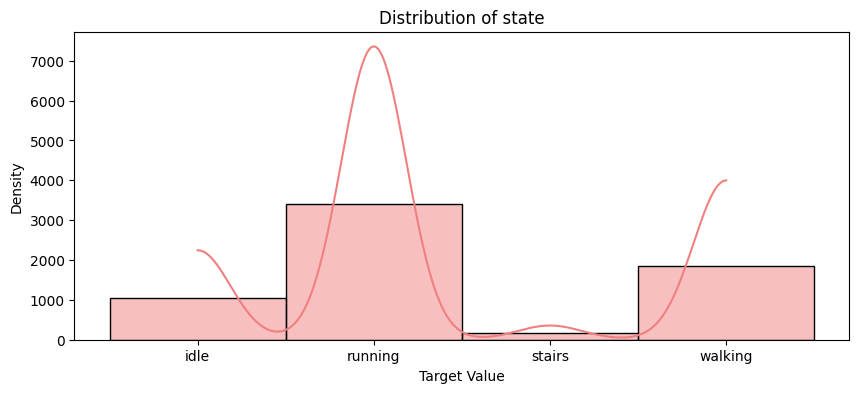

In [23]:
target_info(df, TARGET_NAME, transform=None)

The target is severely imbalanced, we must stratify.

In [24]:
# Encoding the target classes
df[TARGET_NAME] = df[TARGET_NAME].map({"running": 1, "walking": 2, "idle": 3, "stairs": 4})
df.head()

,median_X,max_X,min_X,range_X,skew_X,kurt_X,iqr_X,mad_X,entropy_X,idx_max_X,...,fft_max_X,fft_band_power_Y,fft_energy_Y,fft_magnitude_Y,fft_max_Y,fft_band_power_Z,fft_energy_Z,fft_magnitude_Z,fft_max_Z,state
0,-0.271525,4.748541,-1.050064,5.798605,3.839216,15.400041,0.063530,0.520771,1.411478,3,...,7.520355,14.501965,435.058937,4.828593,7.855532,14.506982,435.209455,4.281670,11.798137,3
1,-0.218708,4.883959,-1.001930,5.885889,4.185307,17.579254,0.048072,0.454758,1.080424,1,...,6.736786,16.599271,497.978134,5.127667,11.223024,14.504438,435.133152,4.611639,8.711034,3
2,-0.222546,4.980502,-0.793288,5.773790,4.357639,19.061094,0.112821,0.447480,1.505099,0,...,7.539742,15.874959,476.248784,5.090128,9.082817,15.220474,456.614214,5.436441,7.141850,3
3,-0.130111,4.124432,-1.808506,5.932938,2.350880,8.623102,0.302501,0.502218,1.573017,17,...,7.659817,15.914640,477.439212,5.026615,9.212949,14.841498,445.244934,5.045575,8.265962,3
4,-0.133789,4.072763,-1.793251,5.866014,2.280946,8.083676,0.289441,0.512676,1.683219,15,...,7.997901,15.917459,477.523760,5.002792,9.300545,14.737735,442.132051,4.913642,8.903686,3


Split into 80% train, 20% test + stratify by target and shuffle.

Train shape: (5169, 49)
Test shape: (1293, 49)

Unique target values:


,counts,%
state,,
1,2726,0.530000
2,1480,0.290000
3,831,0.160000
4,132,0.030000


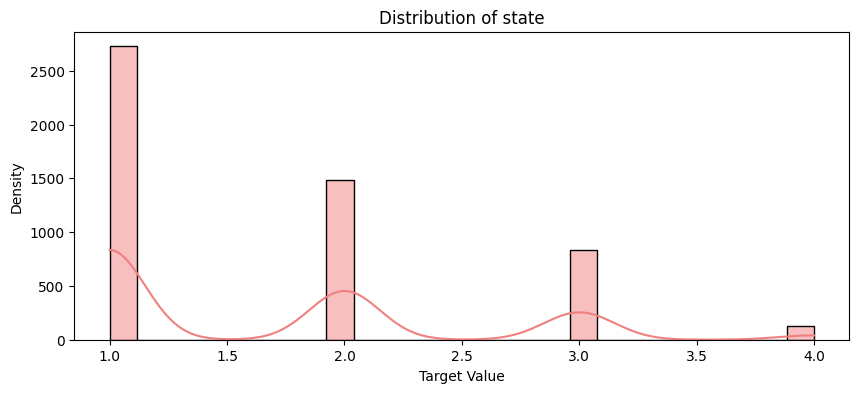

In [25]:
# train-test split (80/20)
X = df.drop(columns=[TARGET_NAME])
y = df[TARGET_NAME]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y, shuffle=True,
)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print()

target_info(df_train, TARGET_NAME)

In [26]:
# save the split
X_train.to_csv(Path('data') / '2 x_train_raw.csv')
y_train.to_csv(Path('data') / '2 y_train_raw.csv')
X_test.to_csv(Path('data') / '2 x_test_raw.csv')
y_test.to_csv(Path('data') / '2 y_test_raw.csv')

Plot the features to understand the nature of the data, how likely it is linear, whether we need to transform anything.

In [ ]:
# output cleared because there are too many features
# plot_features_against_target(
#     data_frame=df_train,
#     features=df_train.columns,
#     target_name=TARGET_NAME,
#     bins={TARGET_NAME: 4},      # specifically 4 bins for the target column
#     imputed_masks=None,         # nothing to highlight separately
#     discrete_threshold=15,      # < 15 unique values -> discrete
# )

The data is highly non-linear, even after the transformations. Linear models are unlikely to perform well without overfitting. If anything, they are going to be purely baseline, not the final predictive power.

### Missing values overview and mechanism

In [ ]:
df_nulls = get_null_info(df)
df_nulls

No missing values are found in the data_frame


""


### Dealing with outliers

The plotted visualized scatter plots above confirmed the presence of anomalies. In this specific domain, hardware glitches in raw accelerometer data are likely (for example, the phone was knocked sharply on the table or the sensor gave a "spike" due to overheating, the batteries might have died etc.). These outliers' nature are intrinsic, which means it will be happening in the future and we want our model to capture that. Therefore, dropping the anomalies is out of the question. 

To preserve this nature, we are going to use an automated winsorization. There are too many features to assess each visually anyway. Also, the data is very skewed, which is ideal for IQR. Final strategy: calculate winsorization boundaries with IQR, then cap them.

In [28]:
winsor_limits, winsorized_masks = auto_iqr_winsorization_limits(
    df=df_train,
    target_name=TARGET_NAME,
    k=3.0,                      # only clip extreme outliers
)

median_X  : 0.00% (0 upper and 0 lower) of median_X would be capped (Limits: [-0.5229, 0.4805])
max_X     : 0.00% (0 upper and 0 lower) of max_X would be capped (Limits: [0.3012, 5.2900])
min_X     : 0.00% (0 upper and 0 lower) of min_X would be capped (Limits: [-5.2844, -0.3456])
range_X   : 0.35% (18 upper and 0 lower) of range_X would be capped (Limits: [2.9916, 6.9972])
skew_X    : 0.08% (0 upper and 4 lower) of skew_X would be capped (Limits: [-4.8618, 5.1845])
kurt_X    : 4.86% (251 upper and 0 lower) of kurt_X would be capped (Limits: [-1.3291, 6.3344])
iqr_X     : 0.00% (0 upper and 0 lower) of iqr_X would be capped (Limits: [0.0141, 1.8927])
mad_X     : 2.84% (0 upper and 147 lower) of mad_X would be capped (Limits: [0.5333, 0.8909])
entropy_X : 2.75% (0 upper and 142 lower) of entropy_X would be capped (Limits: [1.6852, 3.2729])
idx_max_X : 0.00% (0 upper and 0 lower) of idx_max_X would be capped (Limits: [0.0000, 29.0000])
idx_min_X : 0.00% (0 upper and 0 lower) of idx_min_X

In [ ]:
# visualize to see how many are going to be clipped to assess whether we need to increase/reduce the k
# plot_features_against_target(
#     data_frame=df_train,
#     features=X_train.columns,
#     target_name=TARGET_NAME,
#     bins={},
#     imputed_masks=winsorized_masks,
#     discrete_threshold=15,
# )

In [ ]:
# 4. Apply clipping to both datasets based on limits from train
for feat, (lower, upper) in winsor_limits.items():
    df_train[feat] = df_train[feat].clip(lower, upper)
    df_test[feat] = df_test[feat].clip(lower, upper)

## Assumptions

### 1. Multicollinearity

we've established the data is not linear and therefore we will either use non-linear SVM, which doesn't use GD, or trees. Neither of those need feature scaling. However, it's always good to have a simple model as a baseline + some assumptions need scaling.

In [30]:
# create and fit the scaler on TRAINING numerical data
scaler = StandardScaler().fit(X_train)

# transform the data
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index) # <--- .transform() strips away the index column + it doesn't return column names!
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# 2. Safely combine features and target (Indices match perfectly)
df_train = pd.concat([X_train, df_train[[TARGET_NAME]]], axis=1)
df_test = pd.concat([X_test, df_test[[TARGET_NAME]]], axis=1)

display(df_train.head())
display(df_test.head())

,median_X,max_X,min_X,range_X,skew_X,kurt_X,iqr_X,mad_X,entropy_X,idx_max_X,...,fft_max_X,fft_band_power_Y,fft_energy_Y,fft_magnitude_Y,fft_max_Y,fft_band_power_Z,fft_energy_Z,fft_magnitude_Z,fft_max_Z,state
1138,-2.041297,0.329309,0.890952,-0.670730,0.937637,-0.213789,-0.732764,0.204300,0.082086,0.406166,...,1.040047,-0.705538,-0.705538,-3.610673,3.465758,-0.706925,-0.706925,0.144134,-0.481076,1
4684,1.237400,-1.771646,-1.504733,-0.094113,-1.750508,0.616241,-0.125309,-0.808429,-0.592370,-0.503582,...,1.019601,0.161594,0.161594,0.012079,-0.067052,-0.763355,-0.763355,-0.584848,0.052437,2
5847,-0.347877,0.368562,-0.032780,0.408938,0.055646,-0.337243,0.517752,0.342875,0.372638,1.429632,...,0.516569,-0.463903,-0.463903,-0.240295,-0.221121,1.070781,1.070781,0.206098,-0.569590,2
1821,-0.463165,0.981834,1.001858,-0.136935,0.710331,-0.106001,0.667130,-0.035561,-0.088043,0.747321,...,2.271572,-0.074850,-0.074850,-0.308042,0.763133,1.045986,1.045986,1.125453,-1.343297,1
866,0.714761,1.351425,0.227954,1.107483,0.491223,0.286748,-0.688731,-0.579949,-0.208465,1.202195,...,-1.354018,0.418766,0.418766,0.737778,-0.745636,0.297454,0.297454,-0.011659,-0.382692,3


,median_X,max_X,min_X,range_X,skew_X,kurt_X,iqr_X,mad_X,entropy_X,idx_max_X,...,fft_max_X,fft_band_power_Y,fft_energy_Y,fft_magnitude_Y,fft_max_Y,fft_band_power_Z,fft_energy_Z,fft_magnitude_Z,fft_max_Z,state
2306,0.333060,-0.460895,0.135283,-0.617550,-0.222131,-0.693115,1.657247,1.101716,0.981185,1.429632,...,-1.013400,-0.471943,-0.471943,0.383740,-1.001243,0.083679,0.083679,-1.097285,-0.503615,1
380,1.227070,-0.586968,-0.043496,-0.543518,-0.385736,-0.549754,0.503602,0.499716,0.953742,-0.958456,...,0.169090,0.353032,0.353032,-0.088221,-0.185009,2.169990,2.169990,0.266971,0.109483,3
3734,1.125629,-0.680363,-1.259937,0.731818,-1.052219,-0.062978,0.388091,0.173212,0.305049,0.633602,...,-0.980307,-0.661267,-0.661267,-0.269768,0.261530,-0.206802,-0.206802,-1.000079,0.942648,1
6106,1.517116,-0.350204,-0.563596,0.281062,-0.372755,-0.451171,1.250452,1.001622,0.118471,0.519884,...,0.020697,0.407423,0.407423,-0.029756,1.291589,0.024785,0.024785,0.102044,-0.054713,2
3294,-1.056392,0.534192,0.902318,-0.476716,0.615872,-0.370725,-0.013614,0.320921,0.129725,0.292447,...,0.600081,-0.700973,-0.700973,-1.445660,1.387327,-0.213112,-0.213112,-1.903528,2.201682,1


In [31]:
# checkpoint (just in case)
df_train_copy = df_train.copy()
df_test_copy = df_test.copy()

Pearson's coefficients. It checks for pair-wise linear multicollinearity. Values approaching $r=\pm1$ means they contain the exact same physical signal and have to be dropped.

In [32]:
correlations = render_correlations(df_train, is_to_plot=False, threshold=0.9)
correlations

,Feature 1,Feature 2,Correlation
0,fft_band_power_Y,fft_energy_Y,1.000000
1,fft_band_power_Z,fft_energy_Z,1.000000
2,fft_band_power_X,fft_energy_X,1.000000
3,kurt_X,entropy_X,-0.900047


In [33]:
correlations['Feature 1'].unique()

array(['fft_band_power_Y', 'fft_band_power_Z', 'fft_band_power_X',
       'kurt_X'], dtype=object)

In [34]:
# drop and check again
df_train = df_train.drop(columns=correlations['Feature 1'].unique())
df_test = df_test.drop(columns=correlations['Feature 1'].unique())
correlations = render_correlations(df_train, is_to_plot=False, threshold=0.9)
correlations

No entries to plot for a threshold of 0.9


,Feature 1,Feature 2,Correlation


This is a check for perfect multicollinearity. If one feature is an EXACT linear combination of others, it must be dropped.

In [35]:
detect_perfect_multicollinearity_via_rank(df_train, TARGET_NAME)

Matrix rank: 41 / 45 features
Perfect multicollinearity detected — 4 exact dependencies.


41

In [39]:
to_drop_qr = find_redundant_columns_qr(df_train, TARGET_NAME)

Rank: 41 / 45
Redundant columns (4): ['sma', 'max_Y', 'min_X', 'range_Z']


In [41]:
df_train = df_train.drop(columns=to_drop_qr)
df_test  = df_test.drop(columns=to_drop_qr)

In [42]:
detect_perfect_multicollinearity_via_rank(df_train, TARGET_NAME)

Matrix rank: 41 / 41 features


41

It checks for linear multivariate collinearity. We would check it purely for inference, since it affects coefficients (it's present in the SE formula for coefficients), but if $VIF$ is huge (e.g., 1000), it is still a concern, meaning something is wrong with the data.

In [44]:
perform_advanced_vif_analysis(df_train, TARGET_NAME, to_scale=False).head(10)

,feature,VIF,theta,matrix_kappa
0,max_X,22.617207,0.066154,20.561958
1,skew_Z,21.294482,0.064191,20.561958
2,skew_X,20.704614,0.063295,20.561958
3,mad_Z,20.028622,0.062254,20.561958
4,min_Y,13.554124,0.051212,20.561958
5,mad_X,12.721584,0.049615,20.561958
6,range_X,10.482946,0.045038,20.561958
7,max_Z,10.309529,0.044664,20.561958
8,min_Z,10.272818,0.044584,20.561958
9,skew_Y,10.211555,0.044451,20.561958


VIF maximums ($22.6$, $21.3$, $20.7$) are insignificant for this sample size ($\theta<0.2$).
$\kappa = 20.56$ (moderate multicollinearity geometrically): The data space is already starting to stretch into an ellipsoid. The ratio of the longest axis to the shortest is approximately $20.56$.The matrix is ​​not yet collapsing, but it is no longer a perfectly round sphere. Any linear algorithm will already require L2 regularization. Otherwise, the model might focus too much on a specific squashed axis.

Констатувати, що за критерієм $\theta \le 0.20$ модель є стабільною завдяки об'єму вибірки. Об'єм твоїх даних ($n = 6000$ або близько того) настільки великий, що він повністю поглинає і нейтралізує цей локальний VIF. Бутстреп тут не потрібен, бо математично доведено: твої стандартні помилки стиснуті великою вибіркою, і коефіцієнти моделі будуть стабільними від перезапуску до перезапуску.

### 2. Sample Representativeness

Checking how good train represents test.

In [46]:
psi_scores = calculate_feature_psi(
    x_sample=df_train,
    x_evaluation=df_test,
    target_name=TARGET_NAME,
    num_bins=10,
)

print("\n--- Population Stability Index (PSI) Scores ---")
psi_scores.head(10)


--- Population Stability Index (PSI) Scores ---


iqr_X             0.022817
skew_X            0.022675
max_X             0.020908
kurt_Z            0.017235
entropy_X         0.016007
fft_max_X         0.015721
fft_magnitude_Z   0.015435
fft_magnitude_X   0.013833
median_Y          0.012969
skew_Y            0.012950
Name: PSI_Score, dtype: float64

$PSI < 0.10$: Minimal Shift (The evaluation sample is perfectly representative; no action needed).

### 3. Autocorrelation

In sensor engineering, temporal dependency is a known architectural trait of data that cannot be ignored. Since we compute features over sliding windows, the window at time $t$ inevitably copies information from the window at time $t-1$.

In [51]:
# since we don't have a clear time frame physically, rows are independent, we use the standard statistical benchmark:
max_lag = min(20, min(df_train[TARGET_NAME].value_counts()) / 5)
max_lag

20

In [52]:
screenings = screen_autocorrelation_stage1(
    df=df_train,
    target_name=TARGET_NAME,
    mode="classification",
    alpha=0.05,
    max_lag=max_lag,
)
screenings[screenings['Flagged']]

,Class,Feature,LB_Stat (Lag 20),p-value,Flagged
0,4,min_Z,39.238631,0.006226,True
1,4,mad_Z,39.062398,0.006549,True
2,3,fft_max_Y,36.933853,0.011918,True
3,3,fft_magnitude_Y,36.639782,0.012921,True
4,2,corr_XY,35.525464,0.017478,True
5,4,skew_Z,34.440590,0.023294,True
6,1,range_X,33.807565,0.027456,True
7,4,entropy_Z,33.730185,0.028009,True
8,2,corr_XZ,33.688905,0.028308,True
9,2,fft_magnitude_X,33.486866,0.029813,True


To check autocorrelation, we need to plot ACF/PACF. In order for the latter to be trustworthy, the data must be stationary.


=== Class 4 | min_Z ===
--- Stationarity check [min_Z] (n=132) ---
ADF  stat=-4.2400  p=0.0006  used_lag=13  -> stationary
KPSS stat=0.1753  p=0.1000  used_lag=1  -> stationary
=> Verdict: STATIONARY


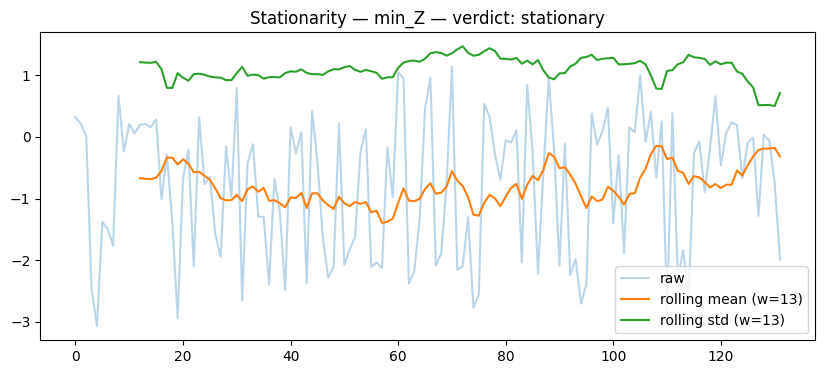


=== Class 4 | mad_Z ===
--- Stationarity check [mad_Z] (n=132) ---
ADF  stat=-9.6885  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.1772  p=0.1000  used_lag=3  -> stationary
=> Verdict: STATIONARY


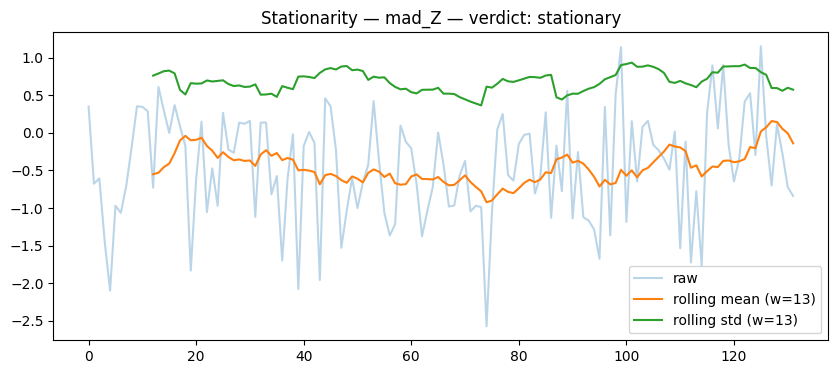


=== Class 3 | fft_max_Y ===
--- Stationarity check [fft_max_Y] (n=831) ---
ADF  stat=-16.1706  p=0.0000  used_lag=4  -> stationary
KPSS stat=0.1432  p=0.1000  used_lag=14  -> stationary
=> Verdict: STATIONARY


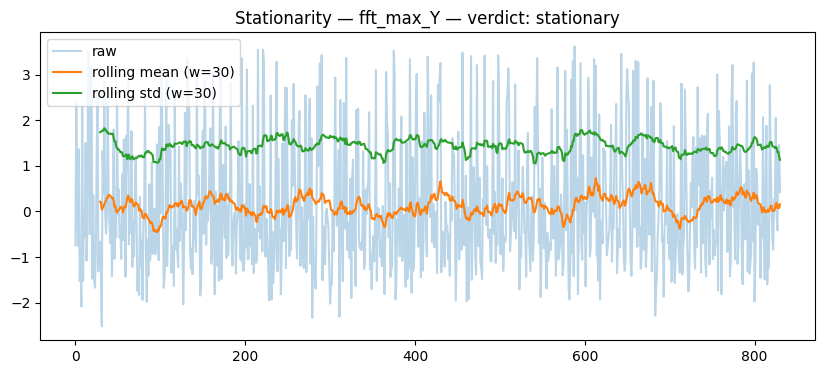


=== Class 3 | fft_magnitude_Y ===
--- Stationarity check [fft_magnitude_Y] (n=831) ---
ADF  stat=-16.0305  p=0.0000  used_lag=4  -> stationary
KPSS stat=0.1643  p=0.1000  used_lag=13  -> stationary
=> Verdict: STATIONARY


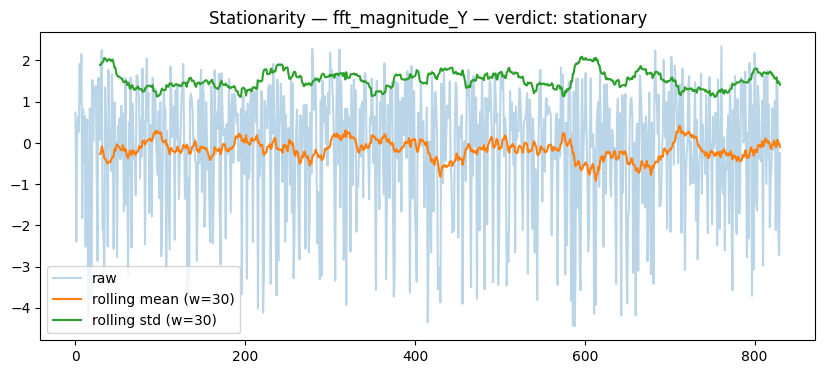


=== Class 2 | corr_XY ===
--- Stationarity check [corr_XY] (n=1480) ---
ADF  stat=-18.5878  p=0.0000  used_lag=3  -> stationary
KPSS stat=0.0240  p=0.1000  used_lag=4  -> stationary
=> Verdict: STATIONARY


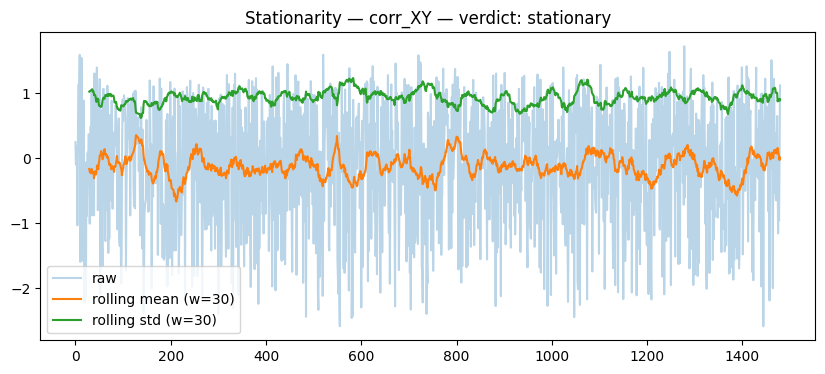


=== Class 4 | skew_Z ===
--- Stationarity check [skew_Z] (n=132) ---
ADF  stat=-4.7650  p=0.0001  used_lag=13  -> stationary
KPSS stat=0.0688  p=0.1000  used_lag=1  -> stationary
=> Verdict: STATIONARY


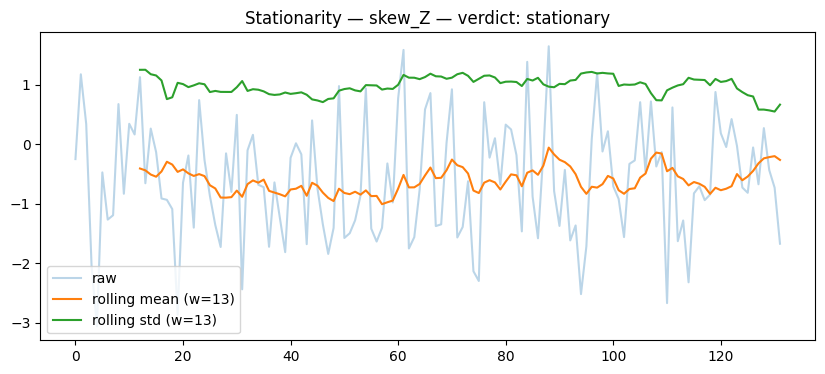


=== Class 1 | range_X ===
--- Stationarity check [range_X] (n=2726) ---
ADF  stat=-53.2549  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.0465  p=0.1000  used_lag=2  -> stationary
=> Verdict: STATIONARY


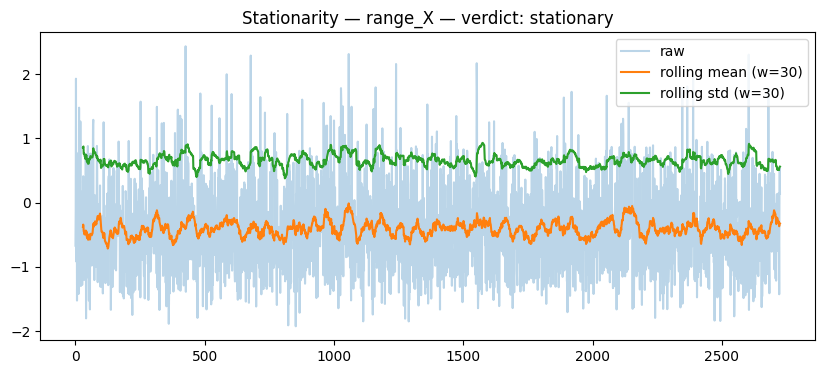


=== Class 4 | entropy_Z ===
--- Stationarity check [entropy_Z] (n=132) ---
ADF  stat=-9.8446  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.2067  p=0.1000  used_lag=2  -> stationary
=> Verdict: STATIONARY


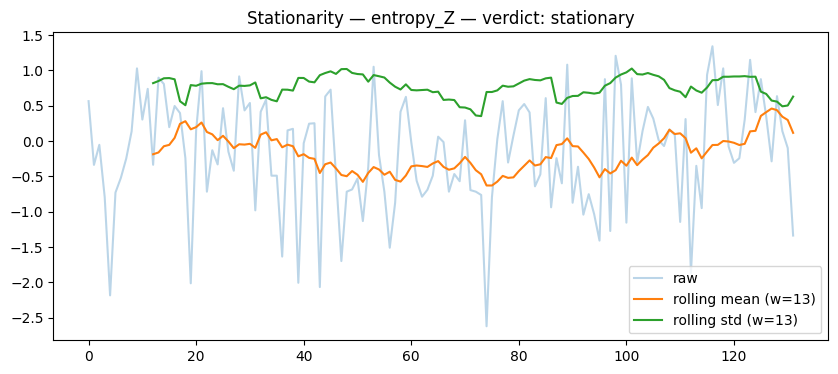


=== Class 2 | corr_XZ ===
--- Stationarity check [corr_XZ] (n=1480) ---
ADF  stat=-11.9443  p=0.0000  used_lag=11  -> stationary
KPSS stat=0.0869  p=0.1000  used_lag=8  -> stationary
=> Verdict: STATIONARY


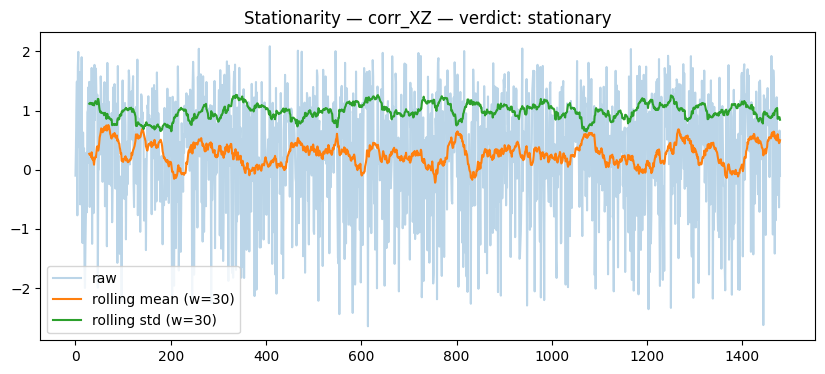


=== Class 2 | fft_magnitude_X ===
--- Stationarity check [fft_magnitude_X] (n=1480) ---
ADF  stat=-38.6272  p=0.0000  used_lag=0  -> stationary
KPSS stat=0.0811  p=0.1000  used_lag=12  -> stationary
=> Verdict: STATIONARY


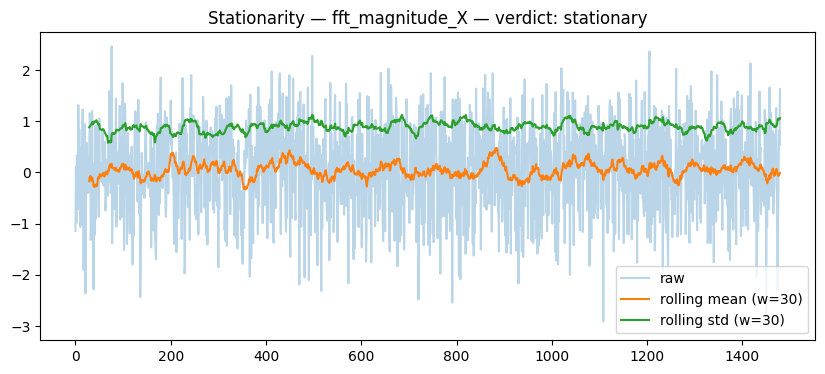


=== Class 3 | idx_max_Y ===
--- Stationarity check [idx_max_Y] (n=831) ---
ADF  stat=-21.2985  p=0.0000  used_lag=1  -> stationary
KPSS stat=0.1006  p=0.1000  used_lag=3  -> stationary
=> Verdict: STATIONARY


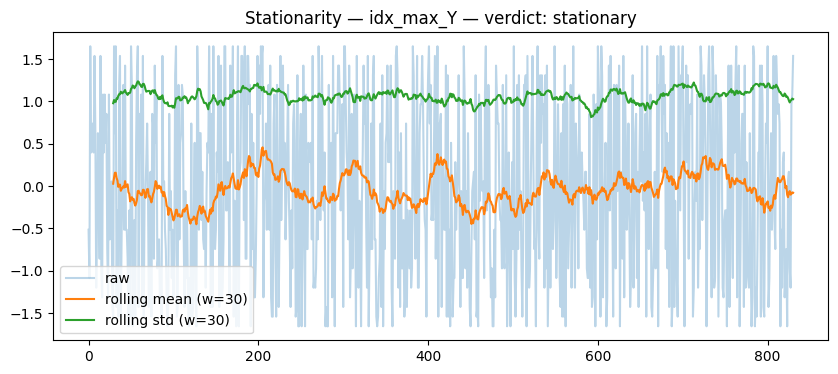


=== Class 3 | fft_energy_X ===
--- Stationarity check [fft_energy_X] (n=831) ---
ADF  stat=-11.4347  p=0.0000  used_lag=7  -> stationary
KPSS stat=0.0659  p=0.1000  used_lag=3  -> stationary
=> Verdict: STATIONARY


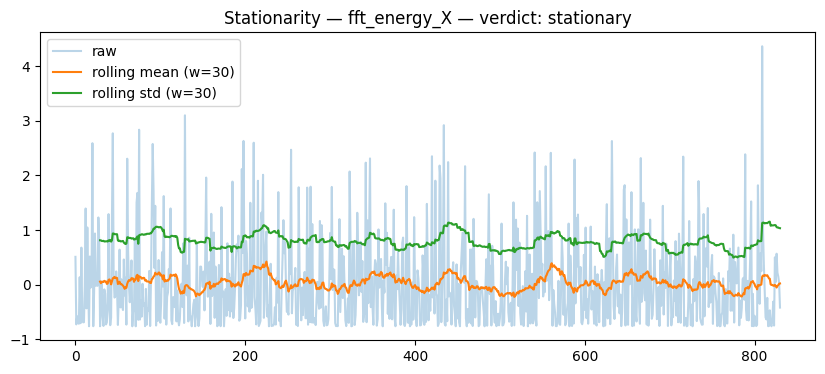


=== Class 4 | fft_magnitude_Y ===
--- Stationarity check [fft_magnitude_Y] (n=132) ---
ADF  stat=-9.1722  p=0.0000  used_lag=1  -> stationary
KPSS stat=0.0834  p=0.1000  used_lag=4  -> stationary
=> Verdict: STATIONARY


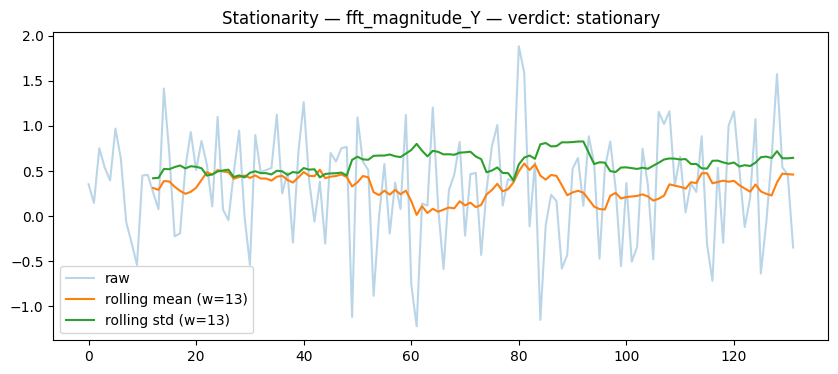

In [54]:
# Classification: run per (class, feature) pair from the Ljung-Box shortlist
flagged = screenings.loc[screenings['Flagged'], ['Class', 'Feature']].drop_duplicates()

for _, row in flagged.iterrows():
    class_label, feat = row['Class'], row['Feature']
    series = df_train[df_train[TARGET_NAME] == class_label][feat]
    print(f"\n=== Class {class_label} | {feat} ===")
    check_stationarity(series, target_name=feat, plot=True)

Stationarity of each suspicious feature was confidently confirmed by both ADF and KPSS, no conflicts.

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


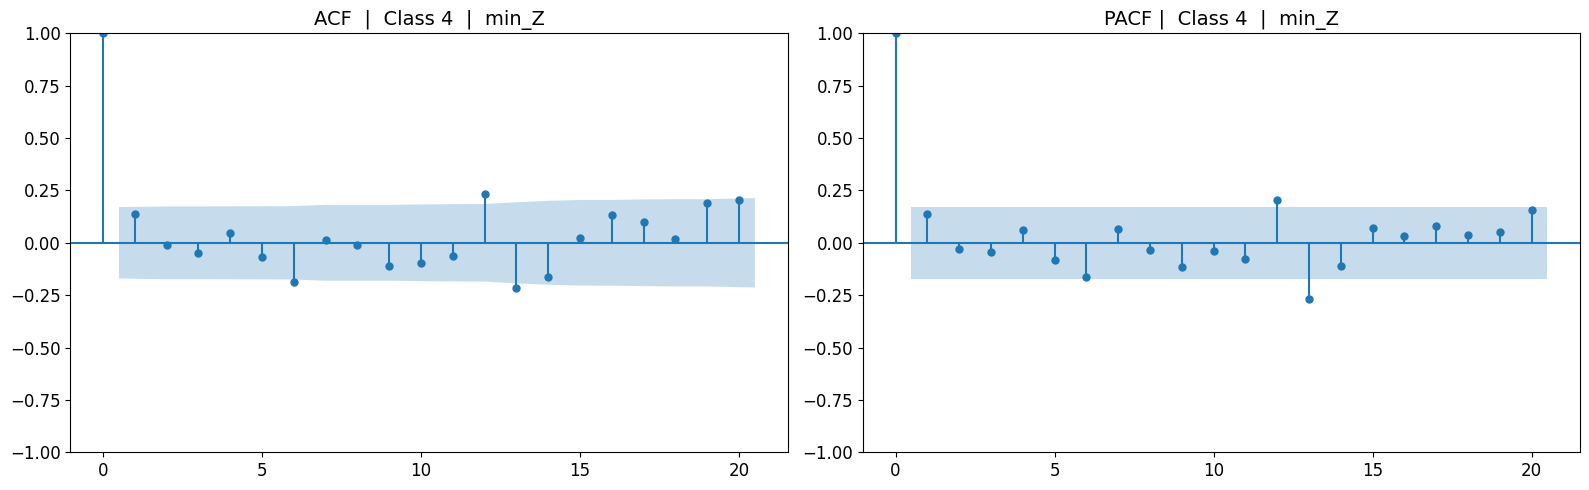

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


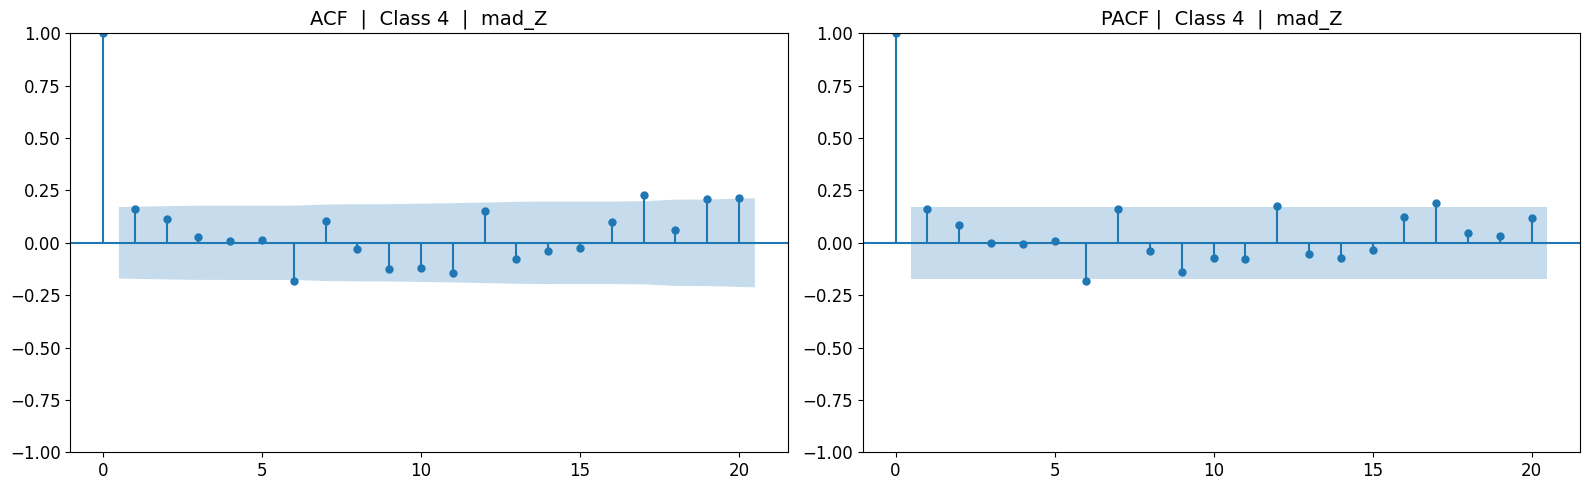

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


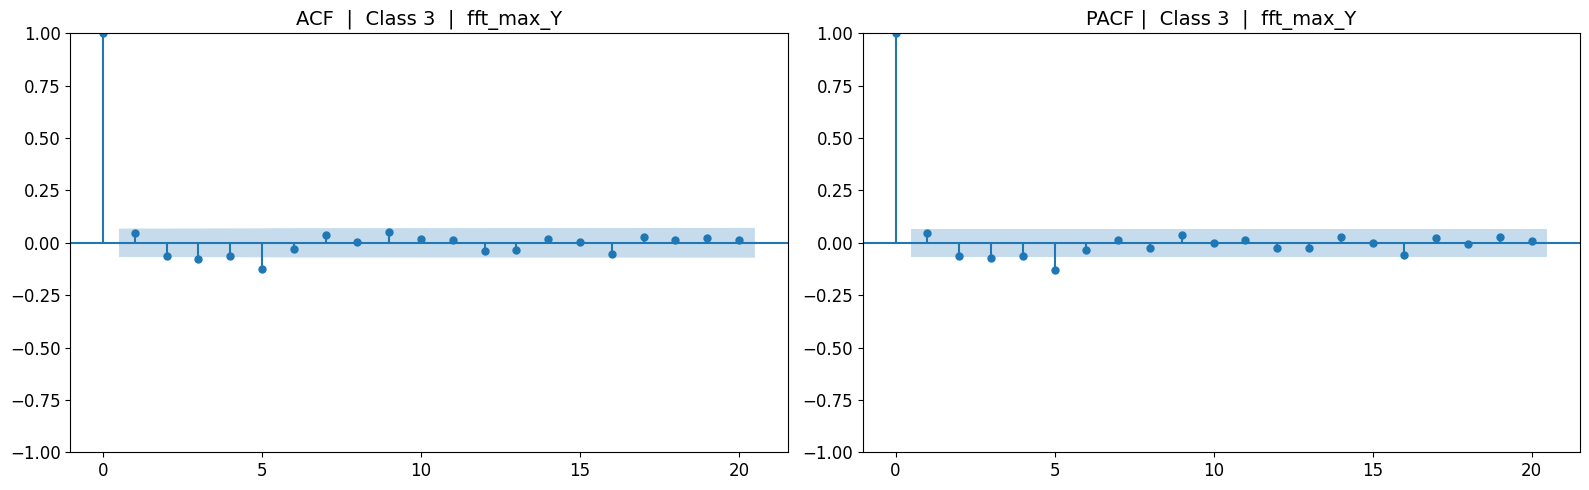

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


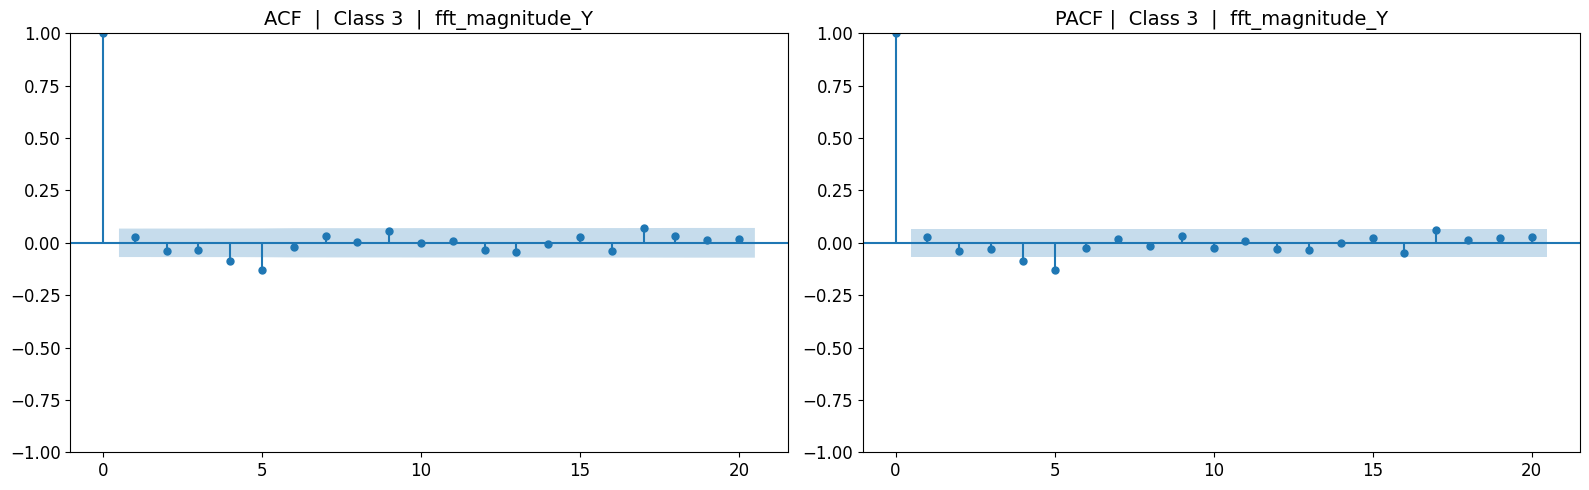

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


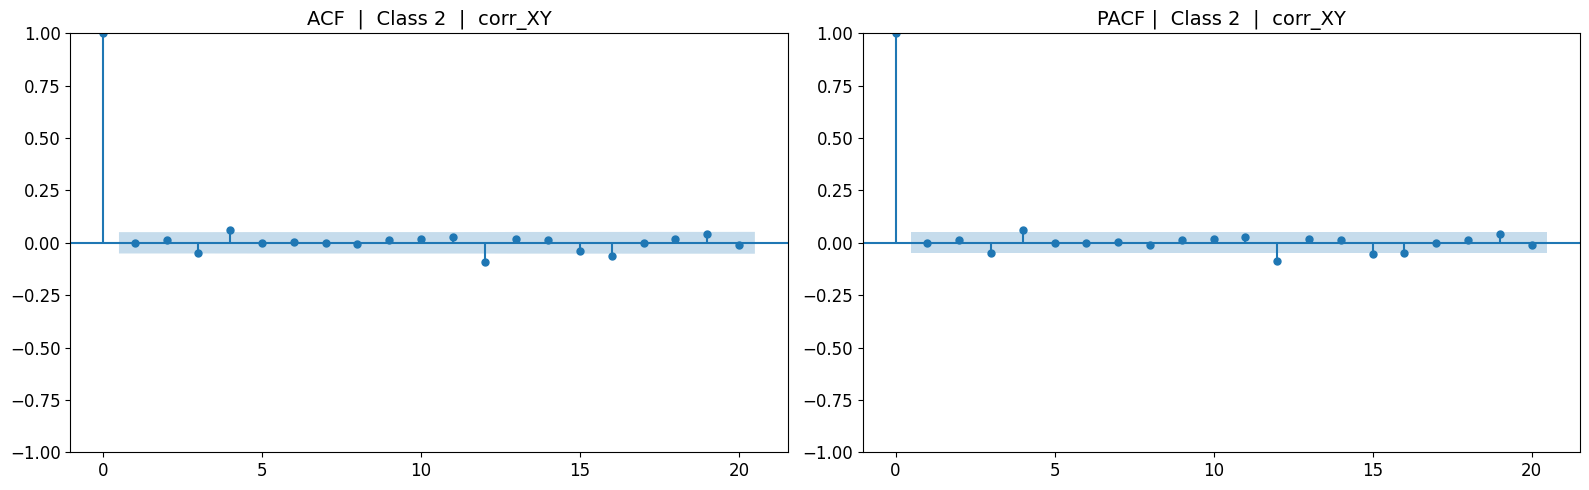

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


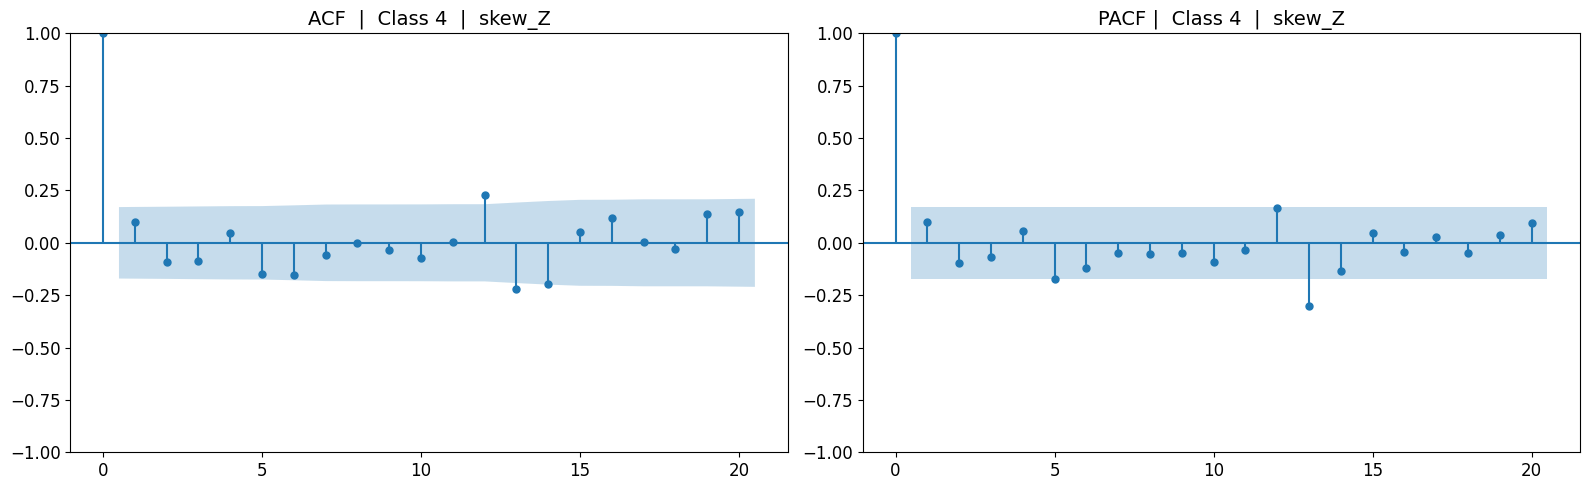

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


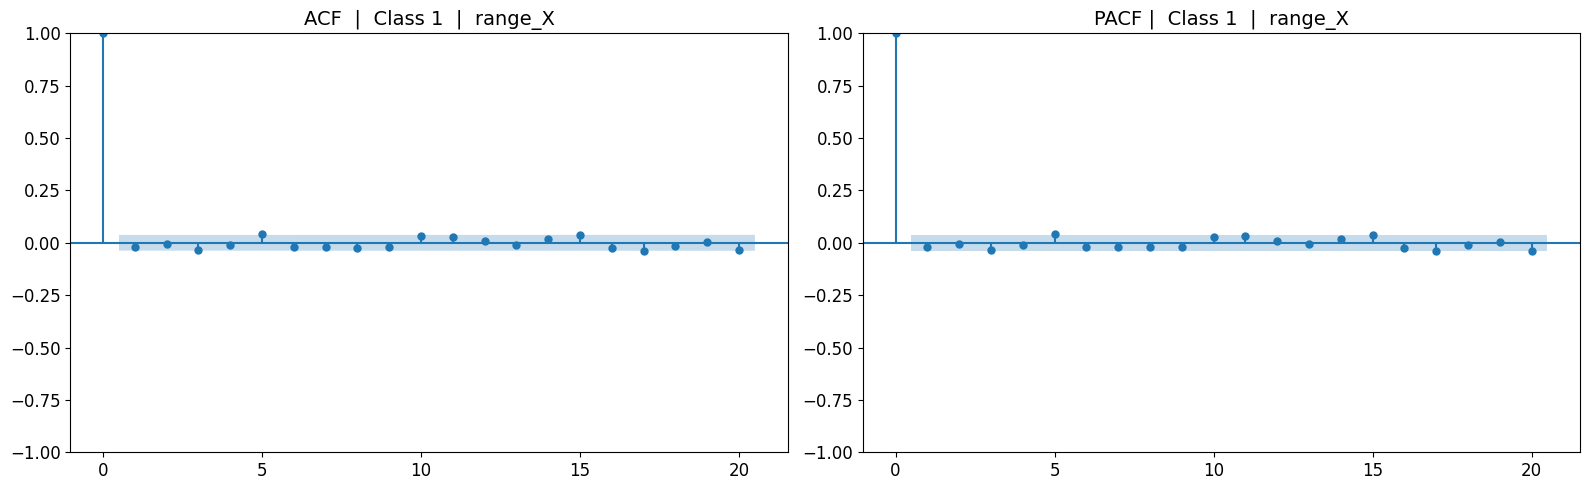

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


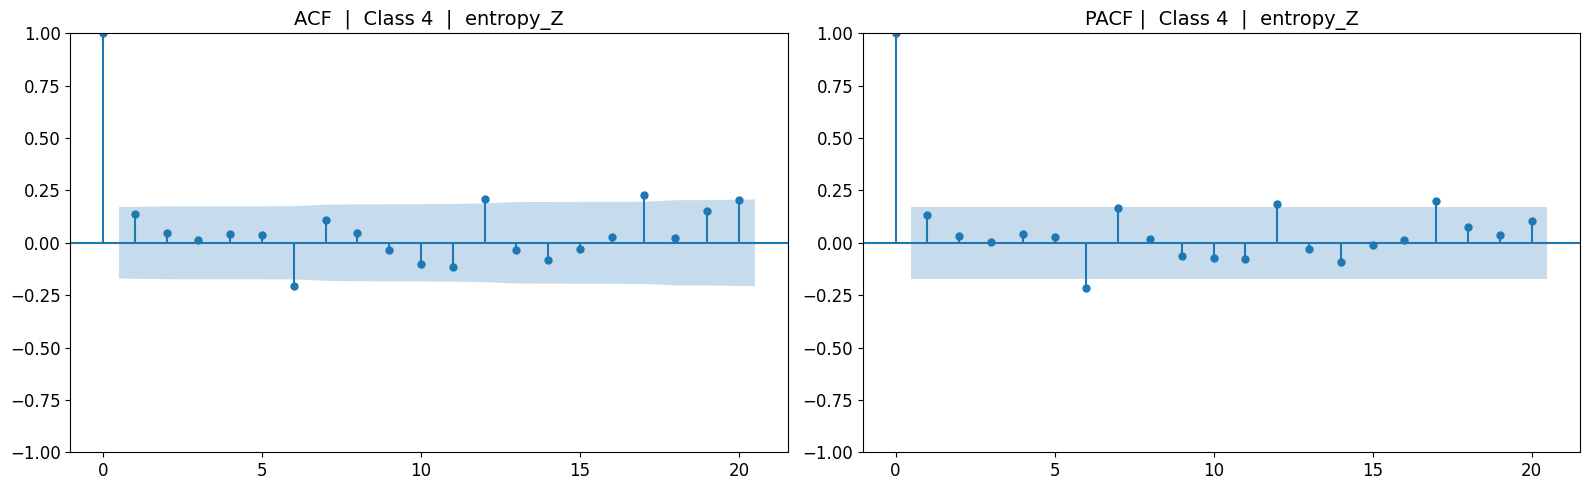

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


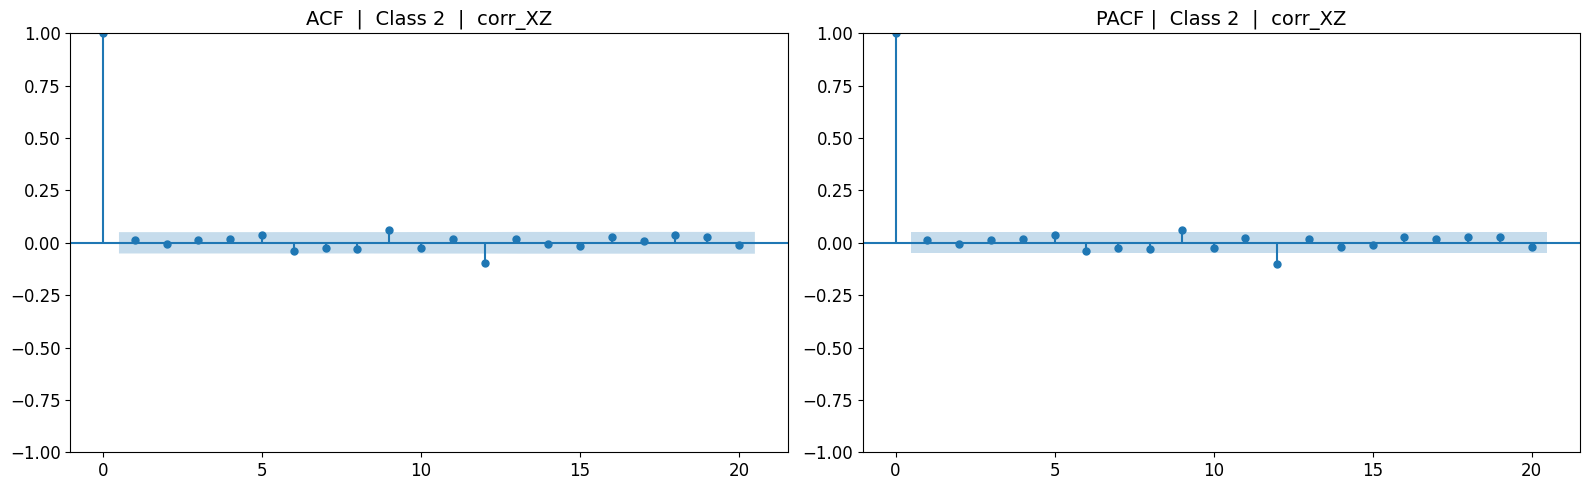

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


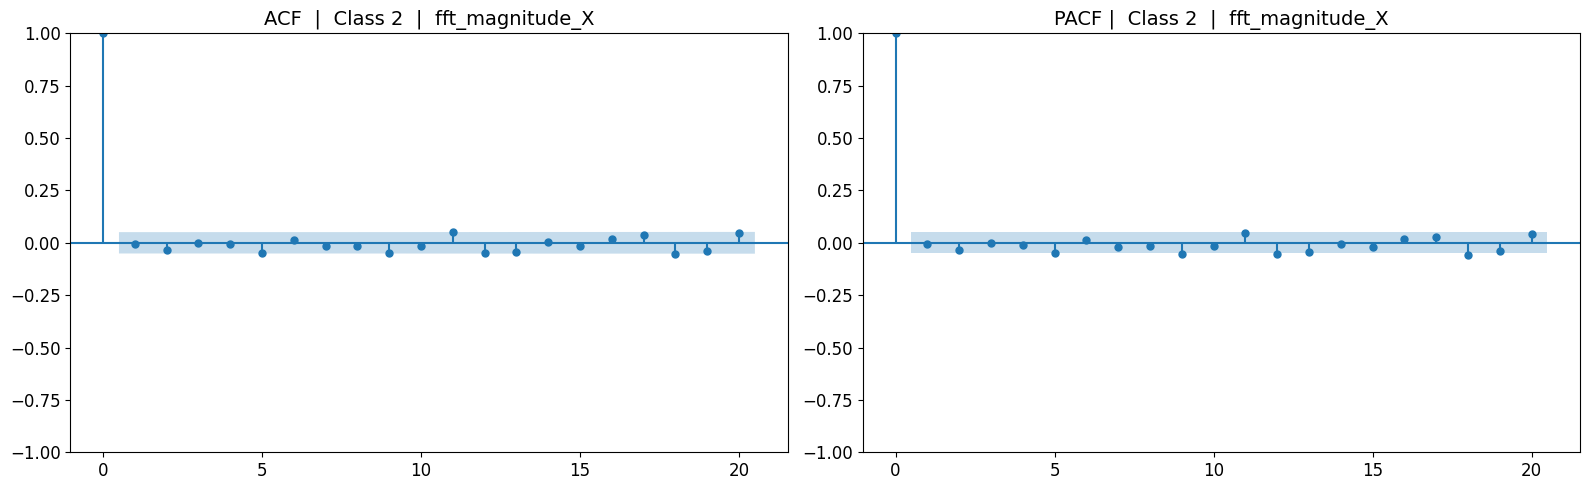

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


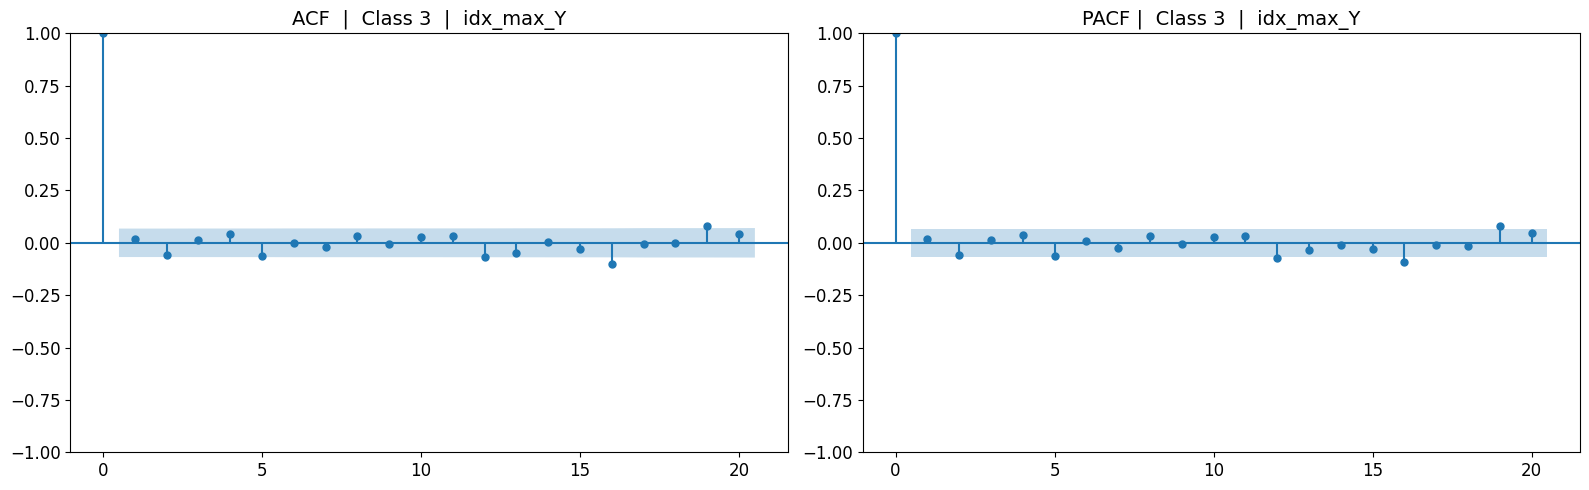

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


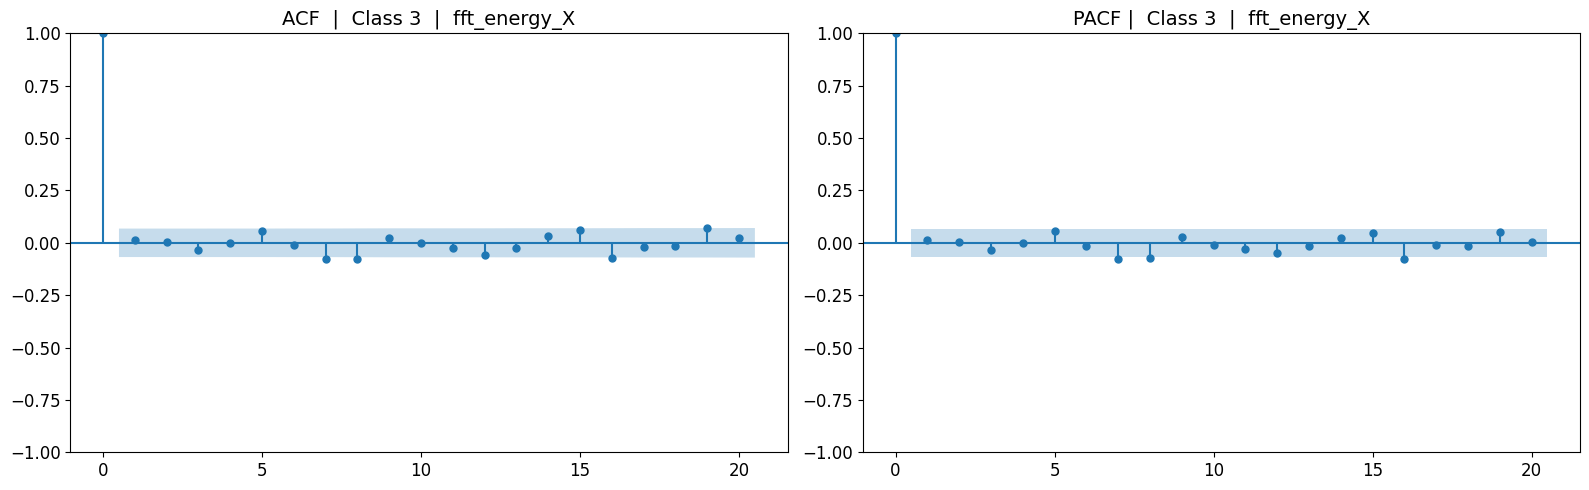

C:\Users\Yur4ik\AppData\Local\Temp\ipykernel_18388\4092598639.py:10: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)


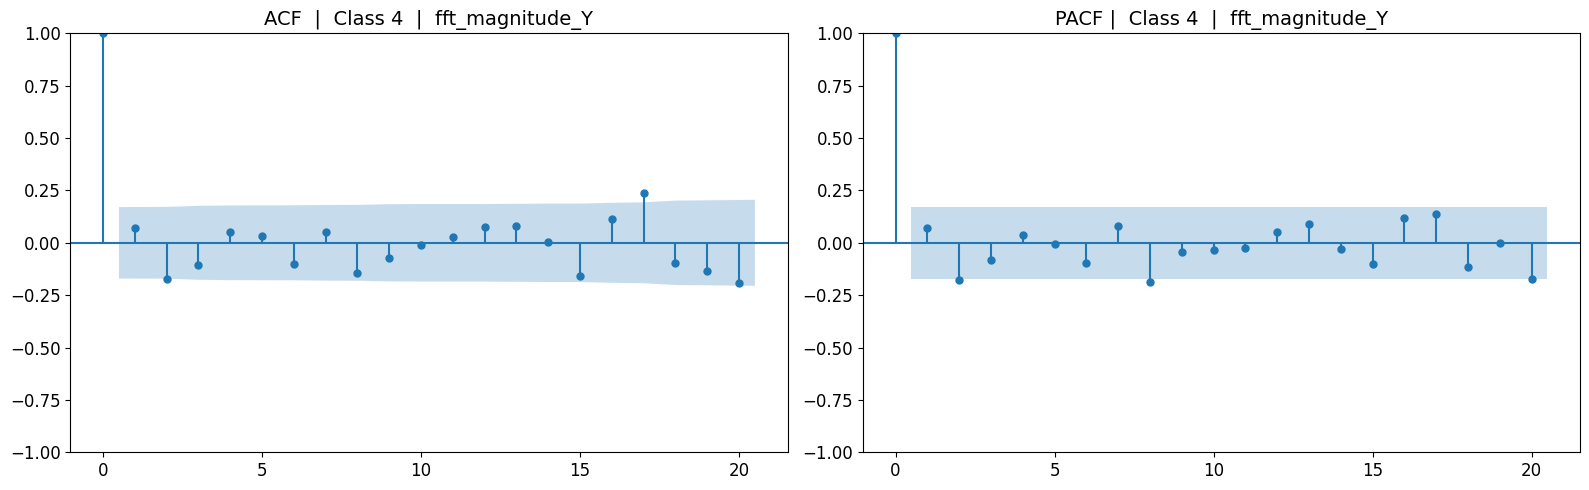

In [56]:
# run per class
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

flagged_features = screenings.loc[screenings['Flagged'], ['Class', 'Feature']].drop_duplicates()
for _, row in flagged_features.iterrows():
    class_label, feat = row['Class'], row['Feature']
    series = df_train[df_train[TARGET_NAME] == class_label][feat].to_numpy()

    fig, axes = plt.subplots(ncols=2, figsize=(16, 5))
    plot_acf( series, lags=max_lag, ax=axes[0], alpha=0.05, unbiased=True)
    plot_pacf(series, lags=max_lag, ax=axes[1], alpha=0.05, method='ywm')
    axes[0].tick_params(axis='both', which='major', labelsize=12)
    axes[1].tick_params(axis='both', which='major', labelsize=12)
    axes[0].set_title(f'ACF  |  Class {class_label}  |  {feat}', fontsize=14)
    axes[1].set_title(f'PACF |  Class {class_label}  |  {feat}', fontsize=14)
    plt.tight_layout()
    plt.show()

Looking at the plots: no actionable autocorrelation is present. With `alpha=0.05`, the confidence band is drawn at the 95% level. By pure probability, we statistically expect 5% of lags to exceed the band even if the series is perfectly random. These are just noise.

Now, to confirm the absence of autocorrelation in residuals of a model (final post-fit check).

In [ ]:
class_labels = sorted(df_train[TARGET_NAME].unique().tolist())
clf_model = ExtraTreesClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_SEED, class_weight="balanced")

residual_check_clf = run_acorr_ljungbox_for_classification_residuals(
    df=df_train,
    target_name=TARGET_NAME,
    class_labels=class_labels,
    model=clf_model,
    max_lag=max_lag,
    alpha=0.05,
)

residual_check_clf

,Class,LB_Stat (Lag 20),p-value,Flagged
0,1,8.957041,0.983400,False
1,2,16.145026,0.707587,False
2,3,16.816225,0.664873,False
3,4,24.157676,0.235572,False


The assumption holds. No autocorrelation in residuals.

## Save the data

In [69]:
df_train.to_csv(Path('data') / '3 df_train_post_EDA.csv', index=False)
df_test.to_csv(Path('data') / '3 df_test_post_EDA.csv', index=False)